# Linear Resampling vs DTW Alignment (Simple Visual Demo)

This notebook shows, with a synthetic example, why linear resampling alone is not enough and how DTW improves phase alignment.

Pipeline shown:
1. Create two curves with the same overall pattern but local speed differences.
2. Linearly resample both to fixed length $L$.
3. Align one curve to the other with DTW.
4. Visualize the warping path and the DTW-aligned result.

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Uses the same package style as your pipeline.py
from dtw import dtw

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')

In [13]:
# --- Helper functions ---
def base_shape(t):
    # Three phases: warm-up bump, plateau oscillation, cool-down dip
    return (
        1.1 * np.exp(-0.5 * ((t - 0.22) / 0.07) ** 2)
        + 0.35 * np.sin(6 * np.pi * t)
        + 0.55 * np.exp(-0.5 * ((t - 0.67) / 0.09) ** 2)
        - 0.65 * np.exp(-0.5 * ((t - 0.88) / 0.05) ** 2)
    )

def make_reference_curve(n=170, noise=0.03):
    t = np.linspace(0, 1, n)
    y = base_shape(t) + noise * np.random.randn(n)
    return t, y

def make_time_distorted_curve(n=135, noise=0.03):
    # Build non-uniform internal clock: faster in one region, slower in another
    t_obs = np.linspace(0, 1, n)
    internal_t = t_obs.copy()

    # Speed-up around early-middle region
    internal_t += 0.10 * np.exp(-0.5 * ((t_obs - 0.35) / 0.10) ** 2)
    # Slow-down around late-middle region
    internal_t -= 0.12 * np.exp(-0.5 * ((t_obs - 0.70) / 0.12) ** 2)

    internal_t = np.clip(internal_t, 0, 1)
    internal_t = np.maximum.accumulate(internal_t)  # enforce monotonicity

    y = base_shape(internal_t) + noise * np.random.randn(n)
    return t_obs, y, internal_t

def linear_resample(y, L):
    x_old = np.linspace(0, 1, len(y))
    x_new = np.linspace(0, 1, L)
    return np.interp(x_new, x_old, y)

def align_curve_with_dtw(query, reference):
    # Same logic as your pipeline helper: map query samples to reference positions
    alignment = dtw(query, reference, keep_internals=True)
    aligned = np.zeros(len(reference))
    counts = np.zeros(len(reference))

    for qi, ri in zip(alignment.index1, alignment.index2):
        aligned[ri] += query[qi]
        counts[ri] += 1

    counts = np.where(counts == 0, 1, counts)
    aligned = aligned / counts
    return aligned, alignment

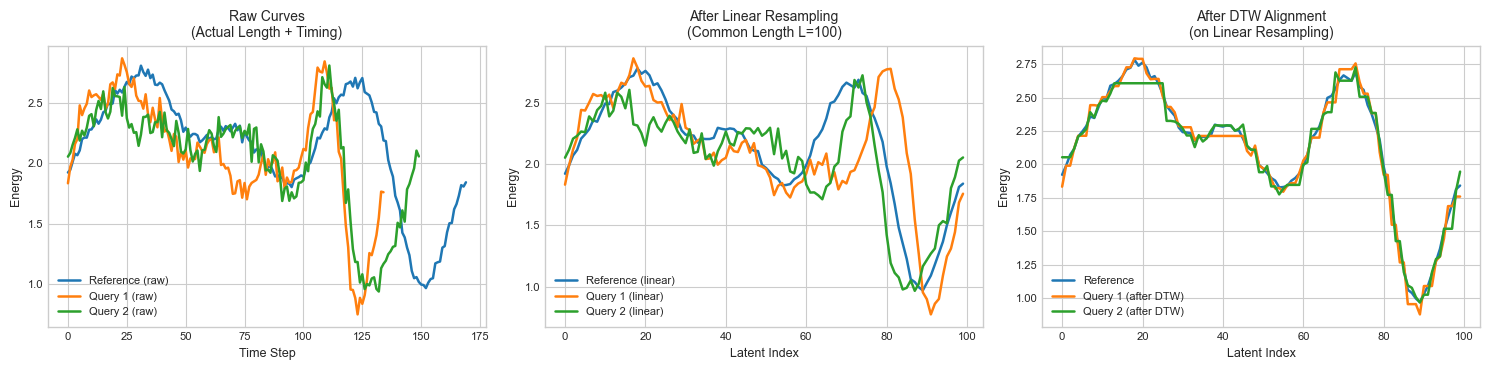

Query 1 MSE (linear only): 0.1315
Query 1 MSE (after DTW) : 0.0028
Query 2 MSE (linear only): 0.0730
Query 2 MSE (after DTW) : 0.0038


In [14]:
# --- One compact visual with 3 curves: 1 reference + 2 queries ---
t_ref, y_ref = make_reference_curve(n=170)

# Query 1: distortion profile A
t_q1, y_q1, _ = make_time_distorted_curve(n=135)

# Query 2: distortion profile B (different local speed changes)
t_q2 = np.linspace(0, 1, 150)
internal_t2 = t_q2.copy()
internal_t2 += 0.14 * np.exp(-0.5 * ((t_q2 - 0.25) / 0.09) ** 2)
internal_t2 -= 0.10 * np.exp(-0.5 * ((t_q2 - 0.62) / 0.10) ** 2)
internal_t2 += 0.06 * np.exp(-0.5 * ((t_q2 - 0.82) / 0.07) ** 2)
internal_t2 = np.clip(internal_t2, 0, 1)
internal_t2 = np.maximum.accumulate(internal_t2)
y_q2 = base_shape(internal_t2) + 0.03 * np.random.randn(len(t_q2))

# Make query curves more different beyond timing (amplitude + local signal + extra noise)
y_q1 = 1.10 * y_q1 + 0.15 * np.sin(10 * np.pi * t_q1) + 0.06 * np.random.randn(len(t_q1))
y_q2 = 0.88 * y_q2 + 0.12 * np.cos(8 * np.pi * t_q2) + 0.08 * np.random.randn(len(t_q2))

# Shift to positive-energy domain and enforce strictly positive values
OFFSET = 1.9
y_ref = np.clip(y_ref + OFFSET, 0.05, None)
y_q1 = np.clip(y_q1 + OFFSET, 0.05, None)
y_q2 = np.clip(y_q2 + OFFSET, 0.05, None)

# Panel A should show actual real length (time steps), not normalized time
x_ref_real = np.arange(len(y_ref))
x_q1_real = np.arange(len(y_q1))
x_q2_real = np.arange(len(y_q2))

# Step 1: linear resampling to common length
L = 100
x_latent = np.arange(L)
y_ref_lin = linear_resample(y_ref, L)
y_q1_lin = linear_resample(y_q1, L)
y_q2_lin = linear_resample(y_q2, L)

# Step 2: DTW alignment on top of linear resampling
y_q1_dtw, _ = align_curve_with_dtw(y_q1_lin, y_ref_lin)
y_q2_dtw, _ = align_curve_with_dtw(y_q2_lin, y_ref_lin)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))

# Panel A: raw different-length curves (3 curves)
axes[0].plot(x_ref_real, y_ref, label='Reference (raw)', linewidth=1.8)
axes[0].plot(x_q1_real, y_q1, label='Query 1 (raw)', linewidth=1.8)
axes[0].plot(x_q2_real, y_q2, label='Query 2 (raw)', linewidth=1.8)
axes[0].set_title('Raw Curves\n(Actual Length + Timing)', fontsize=10)
axes[0].set_xlabel('Time Step', fontsize=9)
axes[0].set_ylabel('Energy', fontsize=9)
axes[0].tick_params(labelsize=8)
axes[0].legend(fontsize=8, loc='best')

# Panel B: after linear resampling (3 curves)
axes[1].plot(x_latent, y_ref_lin, label='Reference (linear)', linewidth=1.8)
axes[1].plot(x_latent, y_q1_lin, label='Query 1 (linear)', linewidth=1.8)
axes[1].plot(x_latent, y_q2_lin, label='Query 2 (linear)', linewidth=1.8)
axes[1].set_title('After Linear Resampling\n(Common Length L=100)', fontsize=10)
axes[1].set_xlabel('Latent Index', fontsize=9)
axes[1].set_ylabel('Energy', fontsize=9)
axes[1].tick_params(labelsize=8)
axes[1].legend(fontsize=8, loc='best')

# Panel C: after DTW alignment (3 curves)
axes[2].plot(x_latent, y_ref_lin, label='Reference', linewidth=1.8)
axes[2].plot(x_latent, y_q1_dtw, label='Query 1 (after DTW)', linewidth=1.8)
axes[2].plot(x_latent, y_q2_dtw, label='Query 2 (after DTW)', linewidth=1.8)
axes[2].set_title('After DTW Alignment\n(on Linear Resampling)', fontsize=10)
axes[2].set_xlabel('Latent Index', fontsize=9)
axes[2].set_ylabel('Energy', fontsize=9)
axes[2].tick_params(labelsize=8)
axes[2].legend(fontsize=8, loc='best')

plt.tight_layout()
plt.show()

mse_q1_linear = np.mean((y_q1_lin - y_ref_lin) ** 2)
mse_q1_dtw = np.mean((y_q1_dtw - y_ref_lin) ** 2)
mse_q2_linear = np.mean((y_q2_lin - y_ref_lin) ** 2)
mse_q2_dtw = np.mean((y_q2_dtw - y_ref_lin) ** 2)

print(f'Query 1 MSE (linear only): {mse_q1_linear:.4f}')
print(f'Query 1 MSE (after DTW) : {mse_q1_dtw:.4f}')
print(f'Query 2 MSE (linear only): {mse_q2_linear:.4f}')
print(f'Query 2 MSE (after DTW) : {mse_q2_dtw:.4f}')

## Interpretation
- **Linear resampling** standardizes length only.
- **DTW** corrects local timing mismatches (phase shifts).
- This is why, in your pipeline, linear resampling is useful as preparation, but DTW still improves phase consistency before model learning.